#### Imports

In [ ]:
import numpy as np 
import pandas as pd 

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [ ]:
from pathlib import Path 
import zipfile
from zipfile import ZipFile 
import torch

In [ ]:
device = torch.device("mps" 
if torch.backends.mps.is_available()
else "cuda" 
if torch.cuda.is_available() 
else "cpu")

In [ ]:
SEED = 42

#### Download data

In [ ]:
data_path = Path("data")
file_path = data_path / "digit_recognizer"
file_path_zip = data_path / "digit-recognizer.zip"

with zipfile.ZipFile(file_path_zip, "r") as ref_zip:
    print(f"Unzipping digit recognizer data in {file_path}...")
    ref_zip.extractall(file_path)

Unzipping digit recognizer data in data/digit_recognizer...


#### Tensor data

In [ ]:
# train_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
# test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

train_path = file_path / "train.csv"
test_path = file_path / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train_np = train_df.drop(columns=["label"]).values
y_train_np = train_df["label"].values
X_test_np = test_df.values

X_train = torch.tensor(X_train_np, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_np, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0 

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: torch.Size([42000, 1, 28, 28])
y_train shape: torch.Size([42000])
X_test shape: torch.Size([28000, 1, 28, 28])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test)

train_dataset, test_dataset

(<torch.utils.data.dataset.TensorDataset at 0x11a474610>,
 <torch.utils.data.dataset.TensorDataset at 0x11a474520>)

#### Visualization data

In [ ]:
import random 
import matplotlib.pyplot as plt 

def plot_images(data: torch.utils.data,
                n: int = 3,
                seed=SEED):
    random.seed(seed)
    random_indexes = random.sample(range(len(data)), k=n)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

    for ax, index in zip(axes, random_indexes):
        img, label = data[index]
        class_name = label.item()

        ax.imshow(img.permute(1, 2, 0), cmap="gray")
        ax.set_title(f"Class: {class_name}", fontsize=25)
        ax.axis(False)
    plt.tight_layout()
    plt.show();

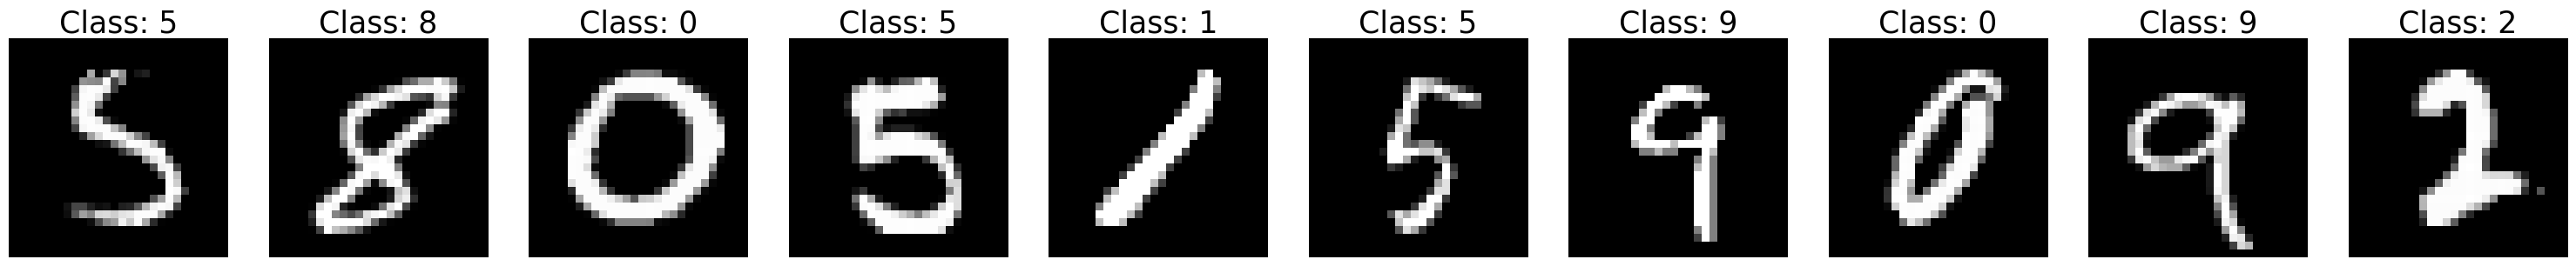

In [ ]:
plot_images(data=train_dataset,
            n=10,
            )

#### Batch data

In [ ]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x11ea665b0>,
 <torch.utils.data.dataloader.DataLoader at 0x11ea4baf0>)

In [ ]:
print(f"Train lenght dataloader: {len(train_dataloader)}")
print(f"Test lenght dataloader: {len(test_dataloader)}")

Train lenght dataloader: 1313
Test lenght dataloader: 875


#### Custom model

In [ ]:
from torch import nn

In [ ]:
classes = torch.unique(y_train).tolist()

In [ ]:
class CustomDigitModelv0(nn.Module):
    def __init__(self, input_shape: int, out_shape: int, hidden_units: int):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=out_shape)
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

custom_model = CustomDigitModelv0(input_shape=1,
                                  out_shape=len(classes),
                                  hidden_units=10).to(device)
custom_model

CustomDigitModelv0(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

#### Train step

In [ ]:
def train_step(model: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               loss_fn: torch.nn.Module,
               dataloader: torch.utils.data.dataloader.DataLoader):
    train_loss, train_acc = 0, 0
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        train_loggits = model(X)
        loss = loss_fn(train_loggits, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_pred = torch.argmax(train_loggits, dim=1)
        acc = (train_loggits == y).sum().item()/len(train_loggits)
        train_acc += acc 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

#### Test step

In [ ]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              dataloader: torch.utils.data.dataloader.DataLoader):
    test_loss, test_acc = 0, 0
    model.eval()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        test_loggits = model(X)
        loss = loss_fn(test_loggits, y)
        test_loss += loss.item()
        test_pred = torch.argmax(test_loggits, dim=1)
        acc = (test_pred == y).sum().item()/len(test_loggits)
        test_acc += acc 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

#### Full step (train + test)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
def full_step(model: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              loss_fn: torch.nn.Module,
              train_dataloader: torch.utils.data.dataloader.DataLoader,
              test_dataloader: torch.utils.data.dataloader.DataLoader,
              epochs: int,
              device:torch.device):
    
    results = {"train_loss": [],
               "test_loss": [],
               "train_acc": [],
               "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           optimizer=optimizer,
                                           loss_fn=loss_fn,
                                           dataloader=train_dataloader)
        test_loss, test_acc = test_step(model=model,
                                        loss_fn=loss_fn,
                                        dataloader=test_dataloader)

        print(f"Epoch: {epoch+1} | ")
        print(f"Train loss: {train_loss:.3f} | ")
        print(f"Test loss: {test_loss:.3f} | ")
        print(f"Train acc: {train_acc:.3f} | ")
        print(f"Test acc: {test_acc:.3f} | ")

        results["train_loss"].append(train_loss)
        results["test_loss"].append(test_loss)
        results["train_acc"].append(train_acc)
        results["test_acc"].append(test_acc)

    return results

#### Loss & Optimizer

In [ ]:
torch.manual_seed(SEED)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=custom_model.parameters(), lr=0.001)

#### Train Custom Model

In [ ]:
torch.manual_seed(SEED)

NUM_EPOCHS = 5

results = full_step(model=custom_model,
                    optimizer=optimizer,
                    loss_fn=loss_fn,
                    train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    epochs=NUM_EPOCHS,
                    device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 2)